# ML Fundamentals #5: Support Vector Machine (SVM)

## Heart Disease Prediction using Support Vector Machine

This project implements a Support Vector Machine classifier to predict the presence of heart disease using patient clinical and diagnostic attributes.

The notebook covers:

- Data Loading
- Dataset Understanding
- Exploratory Data Analysis
- Data Preprocessing
- Feature Scaling
- SVM Model Training
- Prediction
- Model Evaluation
- Kernel Comparison
- Decision Boundary Analysis
- Hyperparameter Tuning
- Model Serialization

In [2]:
# Import required libraries for analysis, visualization, preprocessing, SVM modeling, and evaluation

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib

In [3]:
# Create directories for models, figures, and tables

os.makedirs("models", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

print("Project directories ready.")

Project directories ready.


## 2. Loading the Dataset

This project uses the Heart Disease dataset containing clinical attributes associated with cardiovascular health.

The objective is to classify whether a patient shows the presence or absence of heart disease using a Support Vector Machine classifier.

In [5]:
import pandas as pd

print(pd.__version__)

3.0.6


In [7]:
# Load the Cleveland Heart Disease dataset from the official UCI repository

dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

column_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "target"
]

df = pd.read_csv(
    dataset_url,
    names=column_names,
    na_values="?"
)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [8]:
# Display the dataset dimensions and column names

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nFeatures:")
print(df.columns.tolist())

Rows: 303
Columns: 14

Features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [9]:
# Save the raw dataset locally and export a preview table

df.to_csv("data/raw/heart_disease_cleveland.csv", index=False)

df.head(10).to_csv(
    "outputs/tables/dataset_preview.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


### Dataset Loading Insights

- The Cleveland Heart Disease dataset contains 303 patient records.
- It consists of 13 clinical predictor variables and one diagnosis target variable.
- Missing values represented by `?` in the original data were converted to standard missing values during loading.
- The original target ranges from 0 to 4, where 0 represents absence of heart disease and values 1–4 indicate its presence.
- A local copy of the dataset has been stored for reproducibility.

## 3. Understanding the Dataset

Before preprocessing and model training, the dataset is examined to understand its structure, feature types, statistical characteristics, data quality, and target distribution.

In [10]:
# Examine dataset structure, data types, and non-null values

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


In [11]:
# Generate descriptive statistics for all dataset features

dataset_summary = df.describe().T
dataset_summary

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [12]:
# Save descriptive statistics for later reference

dataset_summary.to_csv("outputs/tables/dataset_summary.csv")

In [13]:
# Check the number and percentage of missing values in each column

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values

,Missing Values,Missing Percentage
age,0,0.00
sex,0,0.00
cp,0,0.00
trestbps,0,0.00
chol,0,0.00
fbs,0,0.00
restecg,0,0.00
thalach,0,0.00
exang,0,0.00
oldpeak,0,0.00


In [14]:
# Save the missing-value analysis

missing_values.to_csv("outputs/tables/missing_values.csv")

In [15]:
# Check the dataset for duplicate patient records

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [16]:
# Examine the original heart disease diagnosis values

target_distribution = df["target"].value_counts().sort_index()

print(target_distribution)

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [17]:
# Save the original target distribution

target_distribution.to_frame(
    name="Count"
).to_csv("outputs/tables/target_distribution_original.csv")

### Dataset Understanding Insights

- The dataset contains 303 observations with 13 predictor variables and one target variable.
- The predictors represent demographic, clinical, electrocardiographic, and exercise-related measurements.
- Missing-value analysis is necessary because the original Cleveland dataset contains unknown values in some attributes.
- Duplicate records are checked before preprocessing to avoid unnecessary repetition in the training data.
- The original diagnosis target uses values from 0 to 4.
- For binary SVM classification, the target will later be transformed into:
  - **0:** No heart disease
  - **1:** Presence of heart disease (original diagnosis 1–4)

## 4. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand the distribution of heart disease cases, examine individual clinical features, and identify relationships among numerical variables before preprocessing and SVM training.

In [18]:
# Create a binary diagnosis variable for exploratory analysis

df_eda = df.copy()
df_eda["heart_disease"] = (df_eda["target"] > 0).astype(int)

df_eda["heart_disease"].value_counts()

heart_disease
0    164
1    139
Name: count, dtype: int64

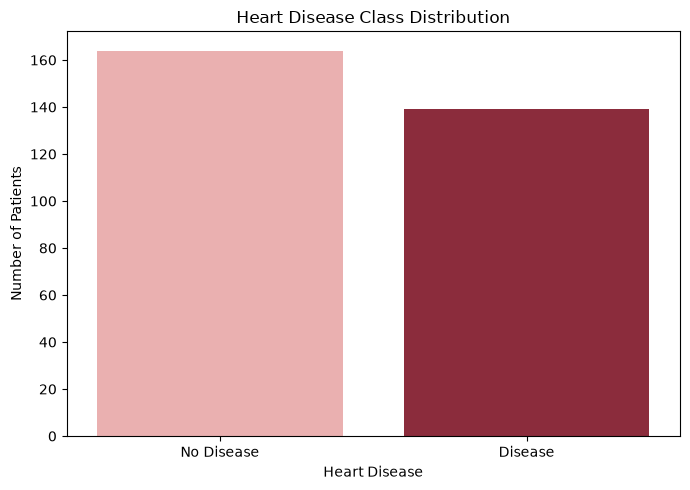

In [19]:
# Visualize the distribution of patients with and without heart disease

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_eda,
    x="heart_disease",
    palette=["#F4A6A6", "#9B1C31"]
)

plt.title("Heart Disease Class Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Disease", "Disease"])

plt.tight_layout()
plt.savefig("outputs/figures/target_distribution.png", dpi=300)
plt.show()

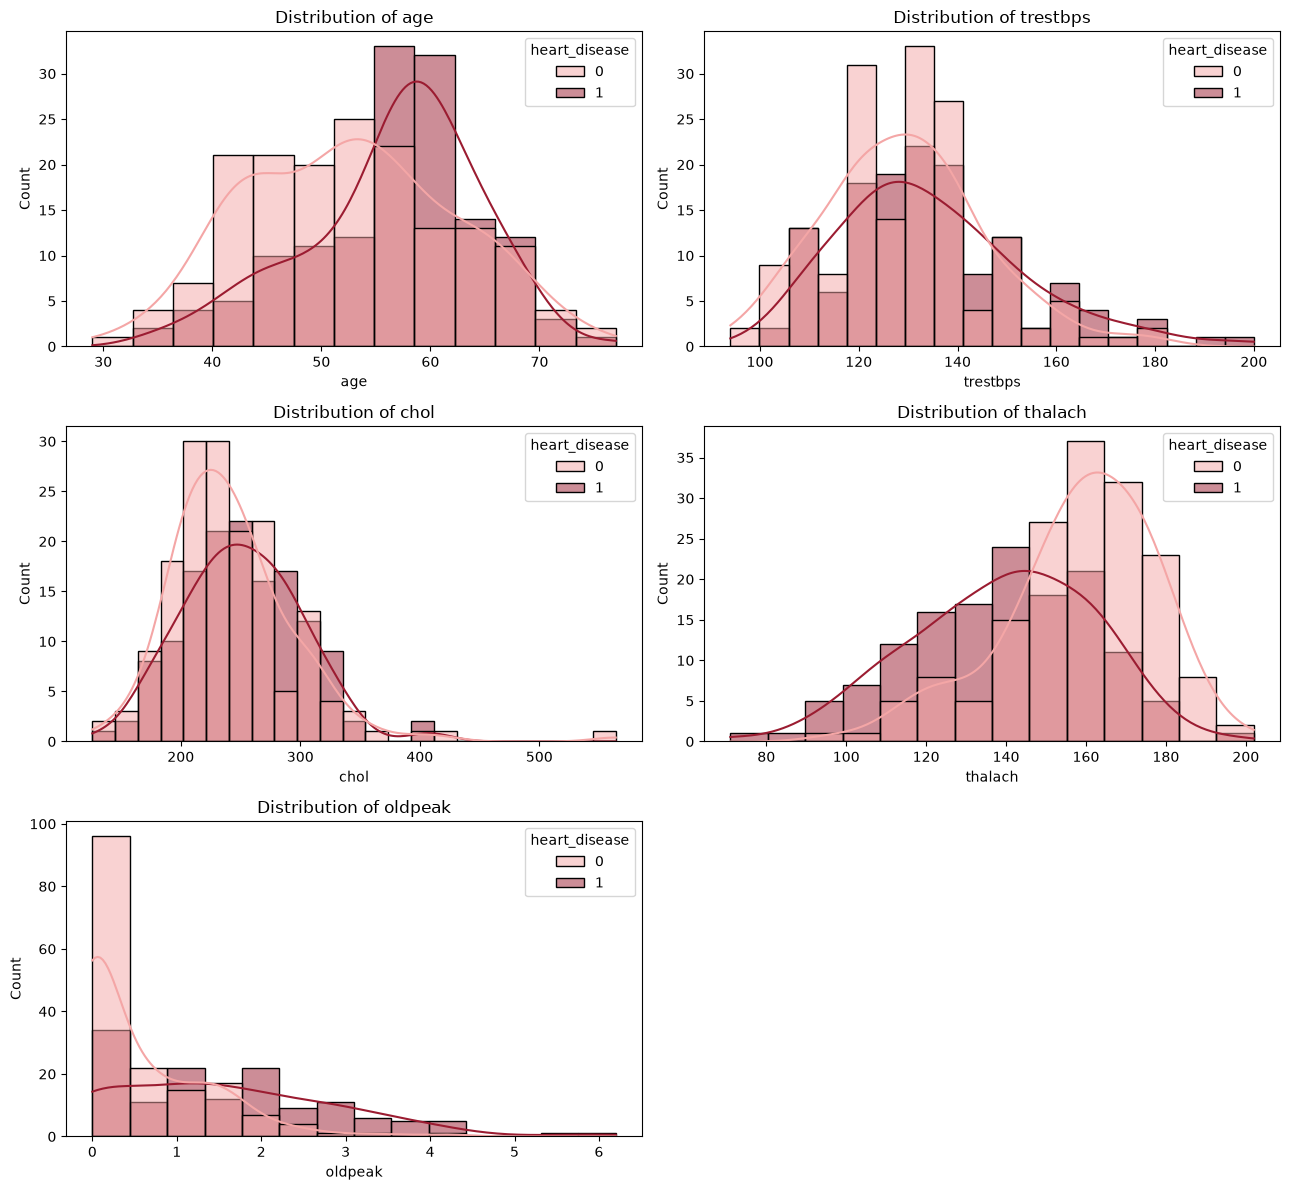

In [20]:
# Visualize distributions of the continuous clinical features

continuous_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

fig, axes = plt.subplots(3, 2, figsize=(13, 12))
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    sns.histplot(
        data=df_eda,
        x=feature,
        hue="heart_disease",
        kde=True,
        palette=["#F4A6A6", "#9B1C31"],
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {feature}")

axes[-1].axis("off")

plt.tight_layout()
plt.savefig("outputs/figures/feature_distributions.png", dpi=300)
plt.show()

In [21]:
# Calculate correlations between numerical features

correlation_matrix = df_eda.corr(numeric_only=True)

correlation_matrix.to_csv(
    "outputs/tables/correlation_matrix.csv"
)

correlation_matrix.round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,heart_disease
age,1.00,-0.10,0.10,0.28,0.21,0.12,0.15,-0.39,0.09,0.20,0.16,0.36,0.13,0.22,0.22
sex,-0.10,1.00,0.01,-0.06,-0.20,0.05,0.02,-0.05,0.15,0.10,0.04,0.09,0.38,0.22,0.28
cp,0.10,0.01,1.00,-0.04,0.07,-0.04,0.07,-0.33,0.38,0.20,0.15,0.23,0.27,0.41,0.41
trestbps,0.28,-0.06,-0.04,1.00,0.13,0.18,0.15,-0.05,0.06,0.19,0.12,0.10,0.13,0.16,0.15
chol,0.21,-0.20,0.07,0.13,1.00,0.01,0.17,-0.00,0.06,0.05,-0.00,0.12,0.01,0.07,0.09
fbs,0.12,0.05,-0.04,0.18,0.01,1.00,0.07,-0.01,0.03,0.01,0.06,0.15,0.07,0.06,0.03
restecg,0.15,0.02,0.07,0.15,0.17,0.07,1.00,-0.08,0.08,0.11,0.13,0.13,0.02,0.18,0.17
thalach,-0.39,-0.05,-0.33,-0.05,-0.00,-0.01,-0.08,1.00,-0.38,-0.34,-0.39,-0.26,-0.28,-0.42,-0.42
exang,0.09,0.15,0.38,0.06,0.06,0.03,0.08,-0.38,1.00,0.29,0.26,0.15,0.33,0.40,0.43
oldpeak,0.20,0.10,0.20,0.19,0.05,0.01,0.11,-0.34,0.29,1.00,0.58,0.30,0.34,0.50,0.42


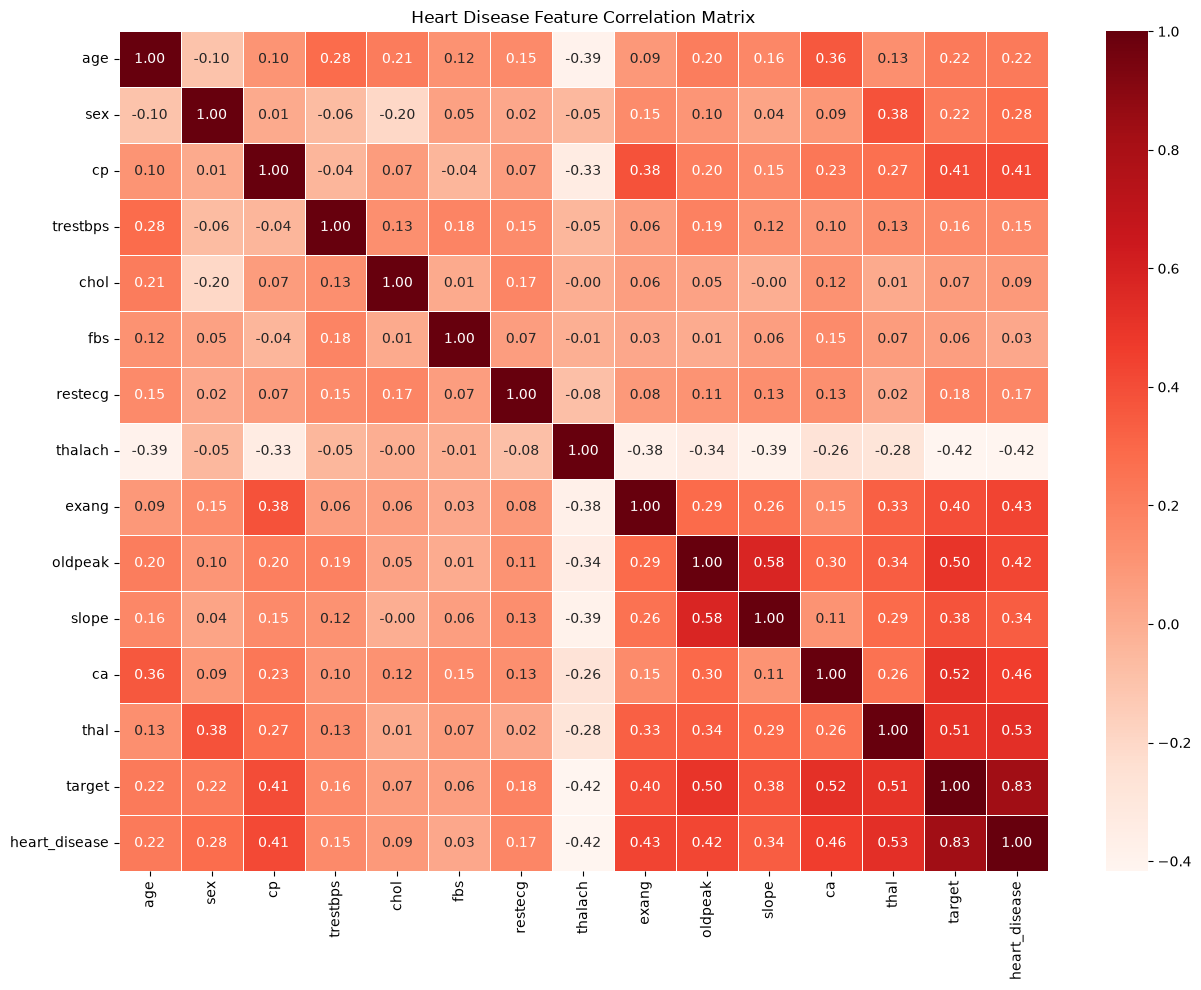

In [22]:
# Visualize relationships among numerical variables using a correlation heatmap

plt.figure(figsize=(13, 10))

sns.heatmap(
    correlation_matrix,
    cmap="Reds",
    annot=True,
    fmt=".2f",
    linewidths=0.4
)

plt.title("Heart Disease Feature Correlation Matrix")

plt.tight_layout()
plt.savefig("outputs/figures/correlation_heatmap.png", dpi=300)
plt.show()

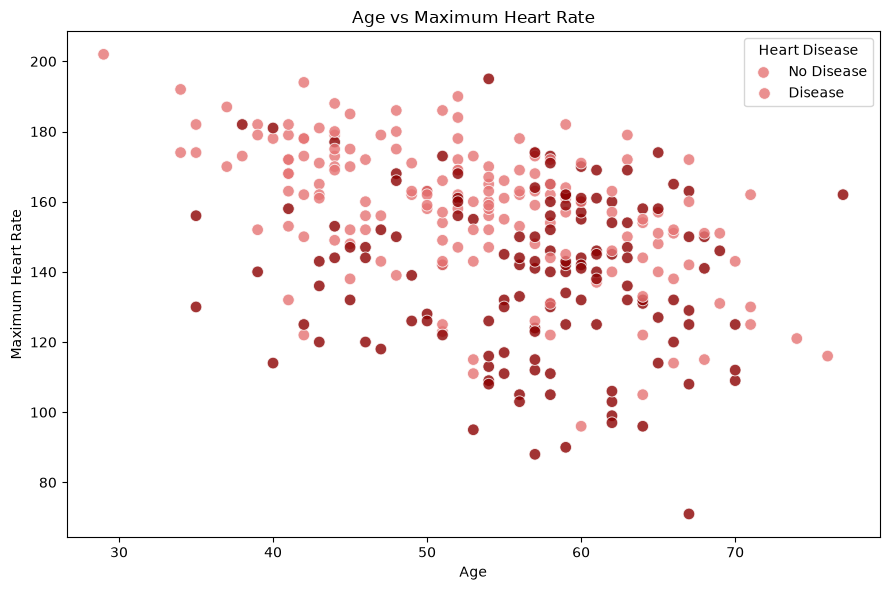

In [23]:
# Examine the relationship between age and maximum heart rate by diagnosis

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_eda,
    x="age",
    y="thalach",
    hue="heart_disease",
    palette=["#E57373", "#8B0000"],
    s=70,
    alpha=0.8
)

plt.title("Age vs Maximum Heart Rate")
plt.xlabel("Age")
plt.ylabel("Maximum Heart Rate")
plt.legend(title="Heart Disease", labels=["No Disease", "Disease"])

plt.tight_layout()
plt.savefig("outputs/figures/age_vs_max_heart_rate.png", dpi=300)
plt.show()

### EDA Insights

- The binary target distribution shows the relative representation of patients with and without diagnosed heart disease.
- Continuous clinical variables exhibit different distributions across the two diagnosis groups.
- The correlation matrix highlights relationships among cardiovascular measurements and the diagnosis variable.
- Age and maximum heart rate provide a useful two-dimensional representation of class overlap, which is particularly relevant when later examining SVM decision boundaries.
- The observed overlap between classes indicates that heart disease classification depends on a combination of clinical features rather than a single measurement.

## 5. Data Preprocessing

The dataset is prepared for Support Vector Machine classification by handling missing values, converting the original diagnosis into a binary target, separating predictors and target, creating stratified training and testing sets, and standardizing the input features.

Feature scaling is particularly important for SVM because its optimization and distance calculations are sensitive to differences in feature magnitude.

In [24]:
# Examine and handle missing values before model training

print("Missing values before preprocessing:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df_clean = df.copy()

for column in df_clean.columns:
    if df_clean[column].isnull().any():
        df_clean[column] = df_clean[column].fillna(df_clean[column].median())

print("\nTotal missing values after preprocessing:", df_clean.isnull().sum().sum())

Missing values before preprocessing:
ca      4
thal    2
dtype: int64

Total missing values after preprocessing: 0


In [25]:
# Convert the original diagnosis values into a binary heart disease target

df_clean["target"] = (df_clean["target"] > 0).astype(int)

print(df_clean["target"].value_counts().sort_index())

target
0    164
1    139
Name: count, dtype: int64


In [26]:
# Separate the clinical predictor variables from the target variable

X = df_clean.drop("target", axis=1)
y = df_clean["target"]

print("Feature matrix:", X.shape)
print("Target vector:", y.shape)

Feature matrix: (303, 13)
Target vector: (303,)


In [27]:
# Split the dataset into stratified training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 242
Testing samples: 61


In [28]:
# Standardize features using statistics learned only from the training data

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data scaled:", X_train_scaled.shape)
print("Testing data scaled:", X_test_scaled.shape)

Training data scaled: (242, 13)
Testing data scaled: (61, 13)


In [29]:
# Save the cleaned dataset and training data for reproducibility

df_clean.to_csv("data/processed/heart_disease_processed.csv", index=False)

pd.DataFrame(
    X_train_scaled,
    columns=X.columns
).to_csv("outputs/tables/training_features_scaled.csv", index=False)

y_train.reset_index(drop=True).to_csv(
    "outputs/tables/training_labels.csv",
    index=False
)

### Preprocessing Insights

- Missing clinical measurements were replaced using the median of their respective features.
- The original diagnosis values were converted into a binary classification target representing absence or presence of heart disease.
- Stratified splitting preserves the target-class proportions across the training and testing sets.
- Standardization transforms the predictors to comparable numerical scales.
- The scaler was fitted exclusively on the training data to prevent data leakage from the test set.
- The resulting scaled feature matrices are ready for SVM model training.

## 6. Support Vector Machine Model Training

A Support Vector Machine classifier is trained using the Radial Basis Function (RBF) kernel.

The RBF kernel allows SVM to construct nonlinear decision boundaries by measuring similarity between observations in a transformed feature space. It is a suitable baseline when the relationship between clinical measurements and the target is not assumed to be linearly separable.

The model is initially trained using standard hyperparameters. Kernel and hyperparameter comparisons are performed in later sections.

In [30]:
# Train the baseline Support Vector Machine classifier using the RBF kernel

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


In [31]:
# Display the principal configuration of the trained SVM model

print("Kernel:", svm_model.kernel)
print("C:", svm_model.C)
print("Gamma:", svm_model.gamma)
print("Number of support vectors:", svm_model.n_support_)
print("Total support vectors:", svm_model.support_vectors_.shape[0])

Kernel: rbf
C: 1.0
Gamma: scale
Number of support vectors: [69 66]
Total support vectors: 135


In [32]:
# Save the number of support vectors identified for each target class

support_vector_summary = pd.DataFrame({
    "Class": ["No Heart Disease", "Heart Disease"],
    "Support Vectors": svm_model.n_support_
})

support_vector_summary.to_csv(
    "outputs/tables/support_vector_summary.csv",
    index=False
)

support_vector_summary


,Class,Support Vectors
0,No Heart Disease,69
1,Heart Disease,66


### Model Training Insights

- An RBF-kernel Support Vector Machine was trained on the standardized clinical features.
- The `C` parameter controls the trade-off between maximizing the margin and penalizing classification errors.
- The RBF kernel enables nonlinear separation between the two diagnostic classes.
- Support vectors are the training observations that directly influence the position of the SVM decision boundary.
- Their number provides useful information about how many observations participate directly in defining the classifier.

## 7. Prediction

The trained Support Vector Machine is now applied to the unseen test set.

Two outputs are generated:

- **Class prediction:** predicts whether heart disease is absent or present.
- **Probability estimate:** provides the model's estimated probability for each class.

These predictions will subsequently be used for comprehensive model evaluation.

In [33]:
# Generate class predictions and probability estimates for the test set

y_pred = svm_model.predict(X_test_scaled)
y_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated:", len(y_pred))

Predictions generated: 61


In [34]:
# Create a table comparing actual and predicted diagnoses

prediction_results = pd.DataFrame({
    "Actual": y_test.reset_index(drop=True),
    "Predicted": y_pred,
    "Disease Probability": y_prob
})

prediction_results["Actual Diagnosis"] = prediction_results["Actual"].map({
    0: "No Heart Disease",
    1: "Heart Disease"
})

prediction_results["Predicted Diagnosis"] = prediction_results["Predicted"].map({
    0: "No Heart Disease",
    1: "Heart Disease"
})

prediction_results.head(10)

,Actual,Predicted,Disease Probability,Actual Diagnosis,Predicted Diagnosis
0,0,0,0.218149,No Heart Disease,No Heart Disease
1,0,1,0.736753,No Heart Disease,Heart Disease
2,0,0,0.057480,No Heart Disease,No Heart Disease
3,0,0,0.119440,No Heart Disease,No Heart Disease
4,0,1,0.641581,No Heart Disease,Heart Disease
5,0,0,0.225538,No Heart Disease,No Heart Disease
6,0,0,0.214807,No Heart Disease,No Heart Disease
7,0,0,0.282767,No Heart Disease,No Heart Disease
8,1,1,0.757619,Heart Disease,Heart Disease
9,0,0,0.172905,No Heart Disease,No Heart Disease


In [35]:
# Save test-set predictions and probability estimates

prediction_results.to_csv(
    "outputs/tables/sample_predictions.csv",
    index=False
)

print("Prediction results saved successfully.")

Prediction results saved successfully.


In [36]:
# Display one example prediction with its actual diagnosis and estimated probability

sample_index = 0

print("Actual diagnosis:",
      prediction_results.loc[sample_index, "Actual Diagnosis"])

print("Predicted diagnosis:",
      prediction_results.loc[sample_index, "Predicted Diagnosis"])

print(
    "Probability of heart disease:",
    round(prediction_results.loc[sample_index, "Disease Probability"], 4)
)

Actual diagnosis: No Heart Disease
Predicted diagnosis: No Heart Disease
Probability of heart disease: 0.2181


### Prediction Insights

- Predictions were generated exclusively from the unseen test observations.
- Each observation receives a binary diagnosis of either no heart disease or heart disease.
- Probability estimates provide additional information about the model's confidence in the positive class.
- Comparing predicted diagnoses with the known test labels provides the basis for evaluating the classifier's generalization performance.

## 8. Model Evaluation

The predictive performance of the baseline RBF Support Vector Machine is evaluated on the unseen test set.

Multiple metrics are considered because accuracy alone does not fully describe classification performance. Precision, recall, F1-score, ROC-AUC, the confusion matrix, and the ROC curve provide complementary views of the model's ability to distinguish between patients with and without heart disease.

In [37]:
# Calculate the primary classification performance metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

evaluation_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Score": [accuracy, precision, recall, f1, roc_auc]
})

evaluation_metrics

,Metric,Score
0,Accuracy,0.852459
1,Precision,0.806452
2,Recall,0.892857
3,F1 Score,0.847458
4,ROC-AUC,0.943723


In [38]:
# Save the evaluation metrics for the final project results

evaluation_metrics.to_csv(
    "outputs/tables/evaluation_metrics.csv",
    index=False
)

print(evaluation_metrics.to_string(index=False))

   Metric    Score
 Accuracy 0.852459
Precision 0.806452
   Recall 0.892857
 F1 Score 0.847458
  ROC-AUC 0.943723


In [39]:
# Generate a detailed classification report for both diagnostic classes

report = classification_report(
    y_test,
    y_pred,
    target_names=["No Heart Disease", "Heart Disease"],
    output_dict=True
)

classification_report_df = pd.DataFrame(report).transpose()

classification_report_df.to_csv(
    "outputs/tables/classification_report.csv"
)

classification_report_df

,precision,recall,f1-score,support
No Heart Disease,0.900000,0.818182,0.857143,33.000000
Heart Disease,0.806452,0.892857,0.847458,28.000000
accuracy,0.852459,0.852459,0.852459,0.852459
macro avg,0.853226,0.855519,0.852300,61.000000
weighted avg,0.857060,0.852459,0.852697,61.000000


In [40]:
# Generate and save the confusion matrix

cm = confusion_matrix(y_test, y_pred)

confusion_matrix_df = pd.DataFrame(
    cm,
    index=["Actual No Disease", "Actual Disease"],
    columns=["Predicted No Disease", "Predicted Disease"]
)

confusion_matrix_df.to_csv(
    "outputs/tables/confusion_matrix.csv"
)

confusion_matrix_df

,Predicted No Disease,Predicted Disease
Actual No Disease,27,6
Actual Disease,3,25


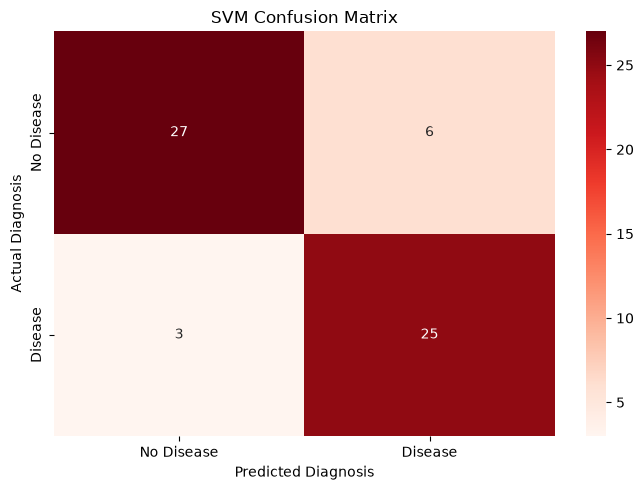

In [41]:
# Visualize correct and incorrect SVM classifications

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"]
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Diagnosis")
plt.ylabel("Actual Diagnosis")

plt.tight_layout()
plt.savefig("outputs/figures/confusion_matrix.png", dpi=300)
plt.show()

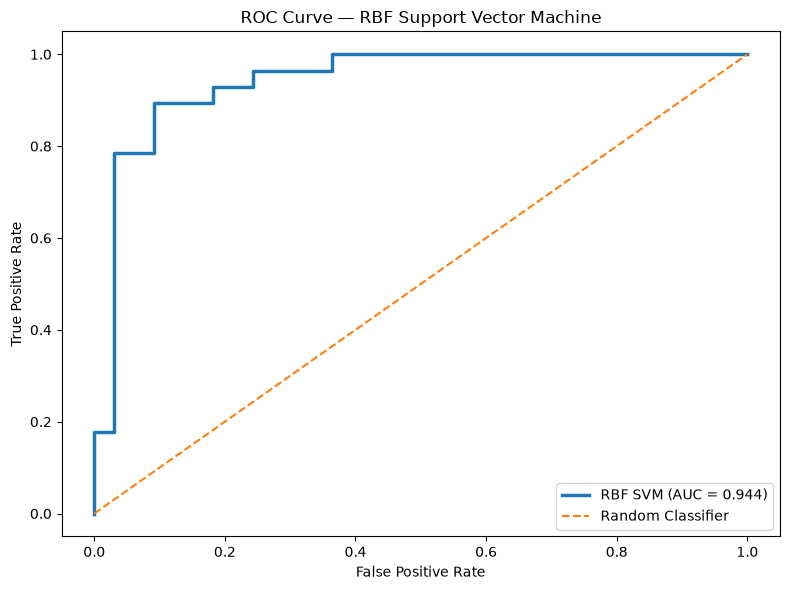

In [42]:
# Calculate and visualize the Receiver Operating Characteristic curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2.5,
    label=f"RBF SVM (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — RBF Support Vector Machine")
plt.legend()

plt.tight_layout()
plt.savefig("outputs/figures/roc_curve.png", dpi=300)
plt.show()

### Evaluation Insights

- Accuracy measures the overall proportion of correctly classified patients.
- Precision indicates how often a positive heart disease prediction is correct.
- Recall measures the proportion of actual heart disease cases successfully identified by the model.
- The F1-score balances precision and recall into a single measure.
- ROC-AUC evaluates the model's ability to distinguish between the two diagnostic classes across classification thresholds.
- The confusion matrix provides a direct view of correct predictions, false positives, and false negatives.

## 9. SVM Kernel Comparison

The kernel function determines how a Support Vector Machine represents the relationship between observations when constructing its decision boundary.

Three commonly used SVM kernels are compared:

- **Linear Kernel:** constructs a linear decision boundary.
- **Polynomial Kernel:** models nonlinear relationships using polynomial transformations.
- **RBF Kernel:** creates flexible nonlinear boundaries based on radial similarity.

All models are trained and evaluated using the same standardized training and testing data to ensure a consistent comparison.

In [43]:
# Train SVM classifiers using Linear, Polynomial, and RBF kernels

kernel_models = {
    "Linear": SVC(kernel="linear", C=1.0, probability=True, random_state=42),
    "Polynomial": SVC(kernel="poly", C=1.0, gamma="scale", probability=True, random_state=42),
    "RBF": SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42)
}

kernel_results = []

for kernel_name, model in kernel_models.items():
    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)
    probabilities = model.predict_proba(X_test_scaled)[:, 1]

    kernel_results.append({
        "Kernel": kernel_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
        "Support Vectors": model.support_vectors_.shape[0]
    })

kernel_comparison = pd.DataFrame(kernel_results)

kernel_comparison

,Kernel,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Support Vectors
0,Linear,0.852459,0.806452,0.892857,0.847458,0.942641,95
1,Polynomial,0.885246,0.838710,0.928571,0.881356,0.959957,148
2,RBF,0.852459,0.806452,0.892857,0.847458,0.943723,135


In [44]:
# Save the kernel performance comparison

kernel_comparison.to_csv(
    "outputs/tables/kernel_comparison.csv",
    index=False
)

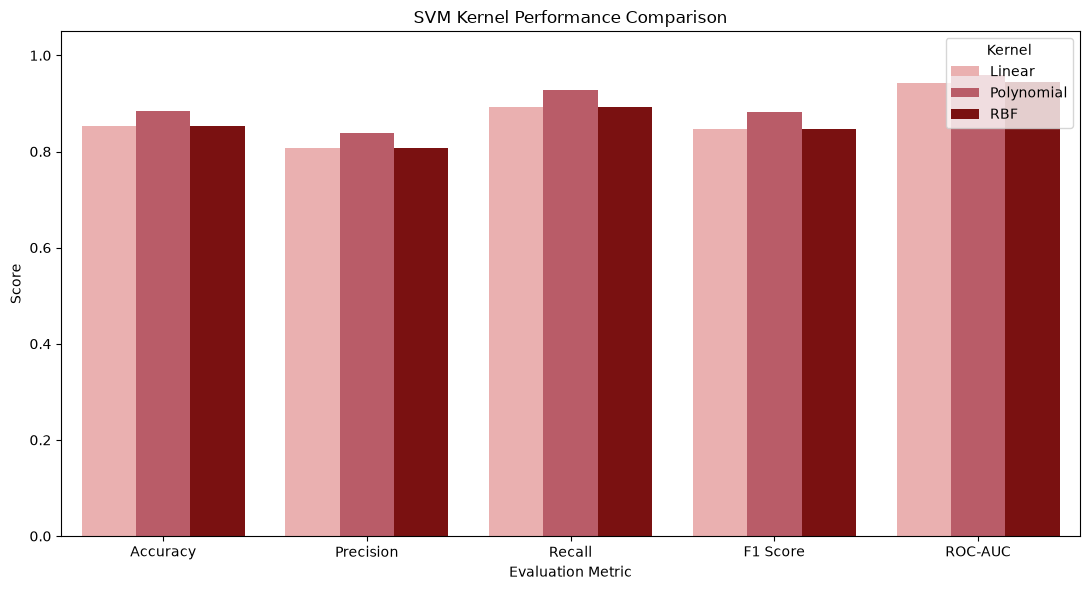

In [45]:
# Compare classification performance across the three SVM kernels

kernel_plot = kernel_comparison.melt(
    id_vars=["Kernel"],
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=kernel_plot,
    x="Metric",
    y="Score",
    hue="Kernel",
    palette=["#F4A6A6", "#C94C5C", "#8B0000"]
)

plt.ylim(0, 1.05)
plt.title("SVM Kernel Performance Comparison")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.legend(title="Kernel")

plt.tight_layout()
plt.savefig("outputs/figures/kernel_comparison.png", dpi=300)
plt.show()

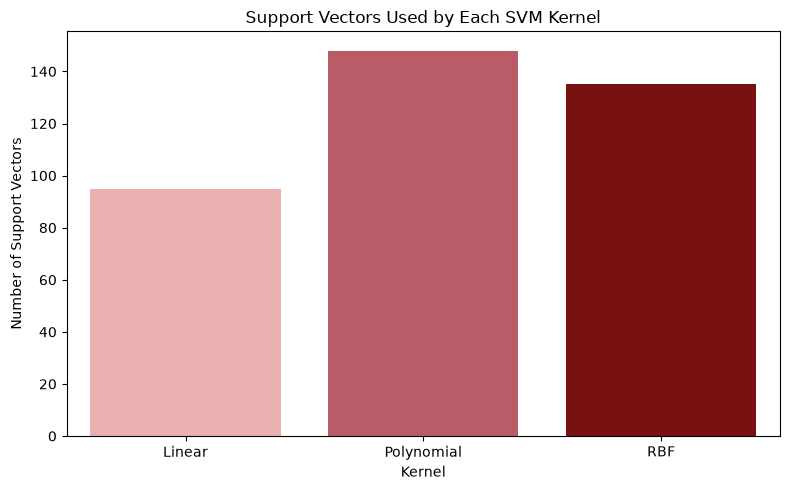

In [46]:
# Compare the number of support vectors required by each kernel

plt.figure(figsize=(8, 5))

sns.barplot(
    data=kernel_comparison,
    x="Kernel",
    y="Support Vectors",
    palette=["#F4A6A6", "#C94C5C", "#8B0000"]
)

plt.title("Support Vectors Used by Each SVM Kernel")
plt.xlabel("Kernel")
plt.ylabel("Number of Support Vectors")

plt.tight_layout()
plt.savefig("outputs/figures/kernel_support_vectors.png", dpi=300)
plt.show()

### Kernel Comparison Insights

- The three kernels represent different assumptions about the geometry of the classification boundary.
- The Linear kernel evaluates whether the standardized clinical features can be separated effectively using a linear hyperplane.
- The Polynomial and RBF kernels allow increasingly nonlinear relationships between the predictors and diagnosis.
- Performance metrics should be considered together rather than selecting a kernel solely from accuracy.
- The number of support vectors also differs between kernels, demonstrating how the choice of kernel changes the observations that directly define the decision boundary.

## 10. SVM Decision Boundary and Support Vector Visualization

A Support Vector Machine constructs a decision boundary that maximizes the separation between classes, while selected training observations known as **support vectors** directly influence the position of this boundary.

The primary heart disease classifier operates in a 13-dimensional feature space, which cannot be represented directly in two dimensions. Therefore, separate visualization models are trained using only **Age** and **Maximum Heart Rate (`thalach`)**.

These two-feature models are used exclusively to demonstrate how different SVM kernels construct decision regions and identify support vectors. They do not replace the full-feature model used for prediction and evaluation.

In [47]:
# Prepare Age and Maximum Heart Rate as a two-dimensional dataset for SVM visualization

X_visual = df_clean[["age", "thalach"]]
y_visual = df_clean["target"]

X_vis_train, X_vis_test, y_vis_train, y_vis_test = train_test_split(
    X_visual,
    y_visual,
    test_size=0.20,
    random_state=42,
    stratify=y_visual
)

visual_scaler = StandardScaler()

X_vis_train_scaled = visual_scaler.fit_transform(X_vis_train)
X_vis_test_scaled = visual_scaler.transform(X_vis_test)



In [48]:
# Define a function to visualize SVM decision regions and support vectors

def plot_svm_boundary(model, X_scaled, y, title, filename):
    x_min, x_max = X_scaled[:, 0].min() - 0.8, X_scaled[:, 0].max() + 0.8
    y_min, y_max = X_scaled[:, 1].min() - 0.8, X_scaled[:, 1].max() + 0.8

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    decision_values = model.decision_function(grid).reshape(xx.shape)

    plt.figure(figsize=(9, 7))

    plt.contourf(
        xx,
        yy,
        decision_values,
        levels=[decision_values.min(), 0, decision_values.max()],
        alpha=0.18,
        cmap="Reds"
    )

    plt.contour(
        xx,
        yy,
        decision_values,
        levels=[-1, 0, 1],
        linestyles=["--", "-", "--"],
        linewidths=[1.2, 2.2, 1.2]
    )

    plt.scatter(
        X_scaled[:, 0],
        X_scaled[:, 1],
        c=y,
        cmap="Reds",
        edgecolors="black",
        s=55
    )

    plt.scatter(
        model.support_vectors_[:, 0],
        model.support_vectors_[:, 1],
        s=150,
        facecolors="none",
        edgecolors="black",
        linewidths=1.8,
        label="Support Vectors"
    )

    plt.xlabel("Standardized Age")
    plt.ylabel("Standardized Maximum Heart Rate")
    plt.title(title)
    plt.legend()

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

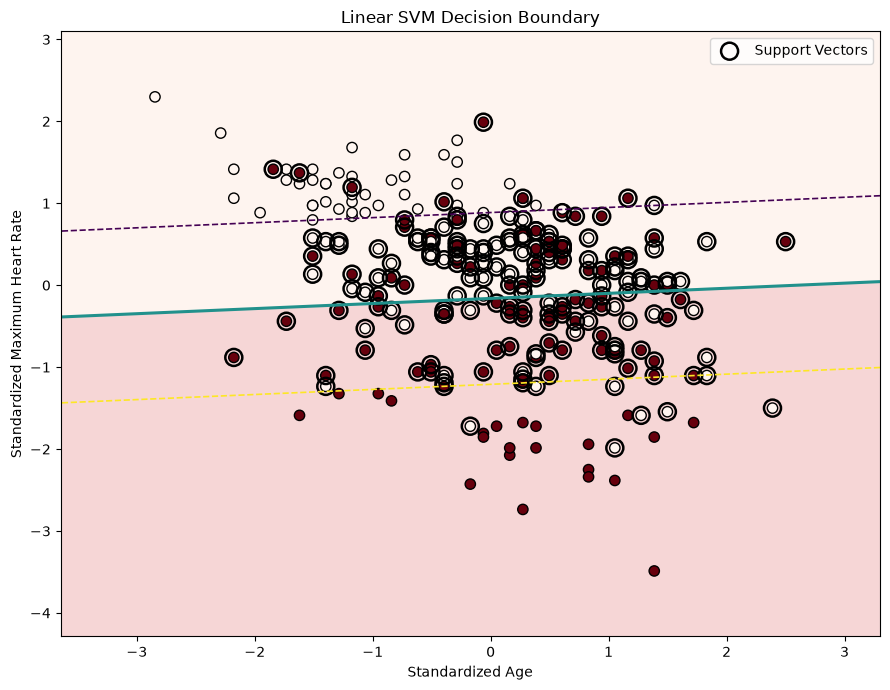

In [49]:
# Train and visualize a two-feature Linear SVM

linear_visual_svm = SVC(
    kernel="linear",
    C=1.0
)

linear_visual_svm.fit(X_vis_train_scaled, y_vis_train)

plot_svm_boundary(
    linear_visual_svm,
    X_vis_train_scaled,
    y_vis_train,
    "Linear SVM Decision Boundary",
    "outputs/figures/linear_svm_decision_boundary.png"
)

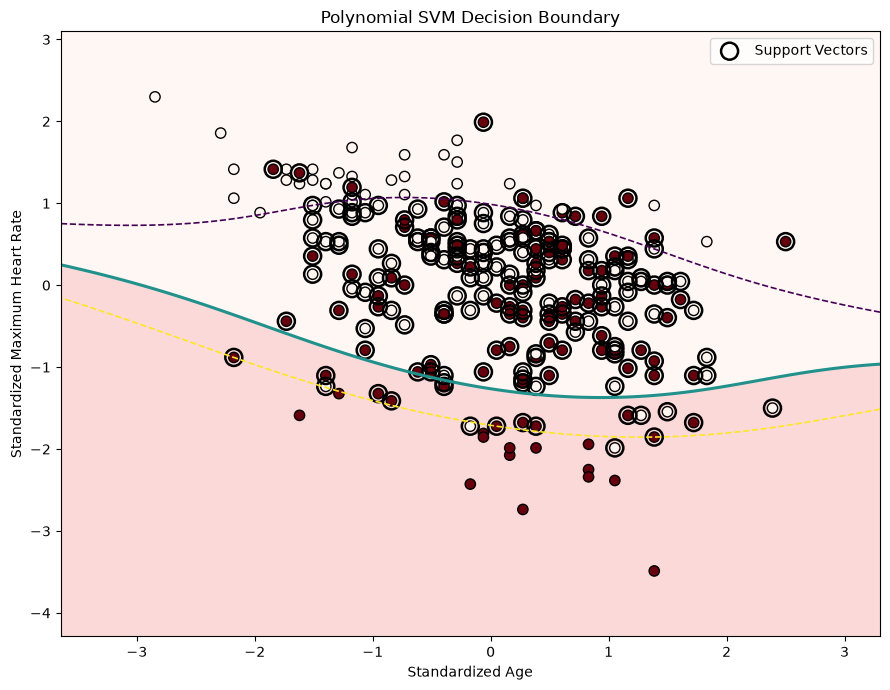

In [50]:
# Train and visualize a two-feature Polynomial SVM

poly_visual_svm = SVC(
    kernel="poly",
    C=1.0,
    gamma="scale"
)

poly_visual_svm.fit(X_vis_train_scaled, y_vis_train)

plot_svm_boundary(
    poly_visual_svm,
    X_vis_train_scaled,
    y_vis_train,
    "Polynomial SVM Decision Boundary",
    "outputs/figures/polynomial_svm_decision_boundary.png"
)

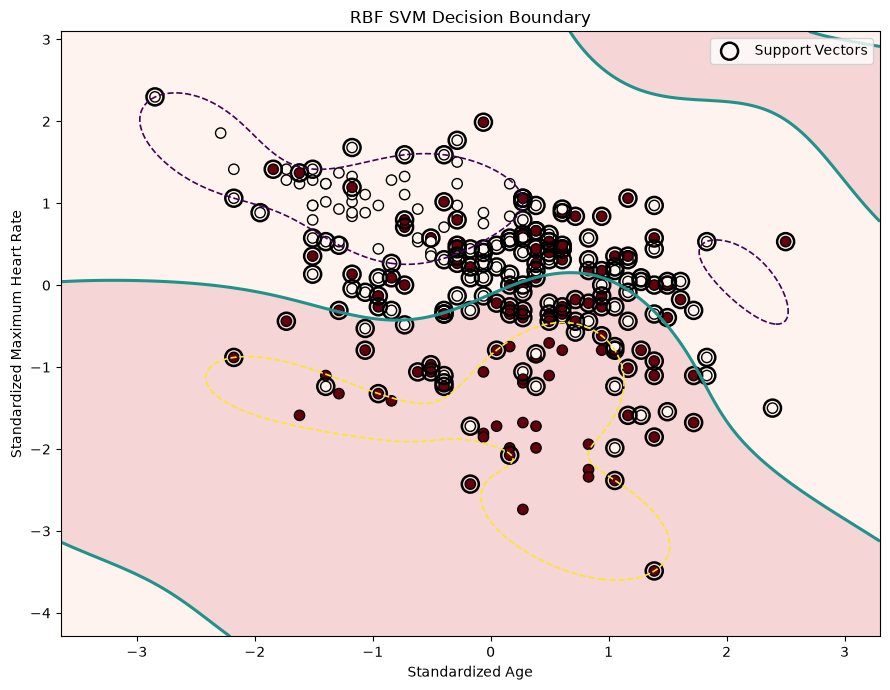

In [51]:
# Train and visualize a two-feature RBF SVM

rbf_visual_svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

rbf_visual_svm.fit(X_vis_train_scaled, y_vis_train)

plot_svm_boundary(
    rbf_visual_svm,
    X_vis_train_scaled,
    y_vis_train,
    "RBF SVM Decision Boundary",
    "outputs/figures/rbf_svm_decision_boundary.png"
)

In [52]:
# Compare the two-dimensional visualization models quantitatively

visual_models = {
    "Linear": linear_visual_svm,
    "Polynomial": poly_visual_svm,
    "RBF": rbf_visual_svm
}

visual_results = []

for name, model in visual_models.items():
    predictions = model.predict(X_vis_test_scaled)

    visual_results.append({
        "Kernel": name,
        "2D Test Accuracy": accuracy_score(y_vis_test, predictions),
        "Support Vectors": model.support_vectors_.shape[0]
    })

visual_comparison = pd.DataFrame(visual_results)

visual_comparison.to_csv(
    "outputs/tables/decision_boundary_comparison.csv",
    index=False
)

visual_comparison

,Kernel,2D Test Accuracy,Support Vectors
0,Linear,0.737705,177
1,Polynomial,0.590164,194
2,RBF,0.737705,173


### Decision Boundary Insights

- The Linear SVM produces a straight separating boundary in the two-dimensional feature space.
- Polynomial and RBF kernels can construct nonlinear decision boundaries to represent more complex class relationships.
- Circled observations represent the support vectors that directly participate in defining each SVM boundary.
- The dashed contours represent margin levels around the central decision boundary.
- Differences in the boundaries demonstrate how kernel selection changes the geometry of an SVM classifier.
- These plots are explanatory two-feature models; the primary heart disease classifier continues to use all 13 clinical predictors.

## 11. SVM Hyperparameter Tuning

Support Vector Machine performance depends strongly on its kernel and hyperparameters.

The principal parameters considered are:

- **C:** controls the trade-off between a wider margin and classification errors.
- **Gamma:** controls the influence of individual training observations for nonlinear kernels.
- **Kernel:** determines the mathematical form of the decision boundary.

Grid Search with stratified 5-fold cross-validation is used to evaluate multiple parameter combinations systematically. ROC-AUC is used as the optimization metric.

In [53]:
# Define the SVM hyperparameter search space

param_grid = [
    {
        "kernel": ["linear"],
        "C": [0.1, 1, 10, 100]
    },
    {
        "kernel": ["rbf"],
        "C": [0.1, 1, 10, 100],
        "gamma": ["scale", "auto", 0.01, 0.1, 1]
    },
    {
        "kernel": ["poly"],
        "C": [0.1, 1, 10],
        "gamma": ["scale", "auto"],
        "degree": [2, 3]
    }
]

grid_search = GridSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

In [54]:
# Perform cross-validated hyperparameter optimization on the training data

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation ROC-AUC:", round(grid_search.best_score_, 6))

Best Parameters: {'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}
Best Cross-Validation ROC-AUC: 0.889462


In [55]:
# Save all hyperparameter combinations and their cross-validation results

grid_results = pd.DataFrame(grid_search.cv_results_)

grid_results = grid_results[
    [
        "params",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

grid_results.to_csv(
    "outputs/tables/hyperparameter_tuning_results.csv",
    index=False
)

grid_results.head(10)

,params,mean_train_score,mean_test_score,std_test_score,rank_test_score
6,"{'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}",0.902051,0.889462,0.045755,1
4,"{'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}",0.917867,0.889102,0.043730,2
5,"{'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}",0.917760,0.889102,0.043730,2
26,"{'C': 0.1, 'degree': 3, 'gamma': 'scale', 'ker...",0.942103,0.888809,0.050406,4
27,"{'C': 0.1, 'degree': 3, 'gamma': 'auto', 'kern...",0.942037,0.888462,0.049391,5
7,"{'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}",0.921116,0.888048,0.045375,6
11,"{'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}",0.914987,0.882742,0.043507,7
0,"{'C': 0.1, 'kernel': 'linear'}",0.913636,0.882023,0.053659,8
16,"{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}",0.936457,0.881721,0.042565,9
10,"{'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}",0.966443,0.880674,0.041906,10


In [56]:
# Retrieve the best SVM identified by cross-validation

best_svm_model = grid_search.best_estimator_

print(best_svm_model)

SVC(C=0.1, gamma=0.01, probability=True, random_state=42)


In [57]:
# Evaluate the tuned SVM on the untouched test set

tuned_pred = best_svm_model.predict(X_test_scaled)
tuned_prob = best_svm_model.predict_proba(X_test_scaled)[:, 1]

tuned_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Score": [
        accuracy_score(y_test, tuned_pred),
        precision_score(y_test, tuned_pred),
        recall_score(y_test, tuned_pred),
        f1_score(y_test, tuned_pred),
        roc_auc_score(y_test, tuned_prob)
    ]
})

tuned_metrics.to_csv(
    "outputs/tables/tuned_model_metrics.csv",
    index=False
)

tuned_metrics

,Metric,Score
0,Accuracy,0.885246
1,Precision,0.920000
2,Recall,0.821429
3,F1 Score,0.867925
4,ROC-AUC,0.963203


In [58]:
# Compare the baseline RBF SVM with the tuned SVM

model_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Baseline SVM": [accuracy, precision, recall, f1, roc_auc],
    "Tuned SVM": tuned_metrics["Score"].values
})

model_comparison.to_csv(
    "outputs/tables/baseline_vs_tuned_svm.csv",
    index=False
)

model_comparison

,Metric,Baseline SVM,Tuned SVM
0,Accuracy,0.852459,0.885246
1,Precision,0.806452,0.920000
2,Recall,0.892857,0.821429
3,F1 Score,0.847458,0.867925
4,ROC-AUC,0.943723,0.963203


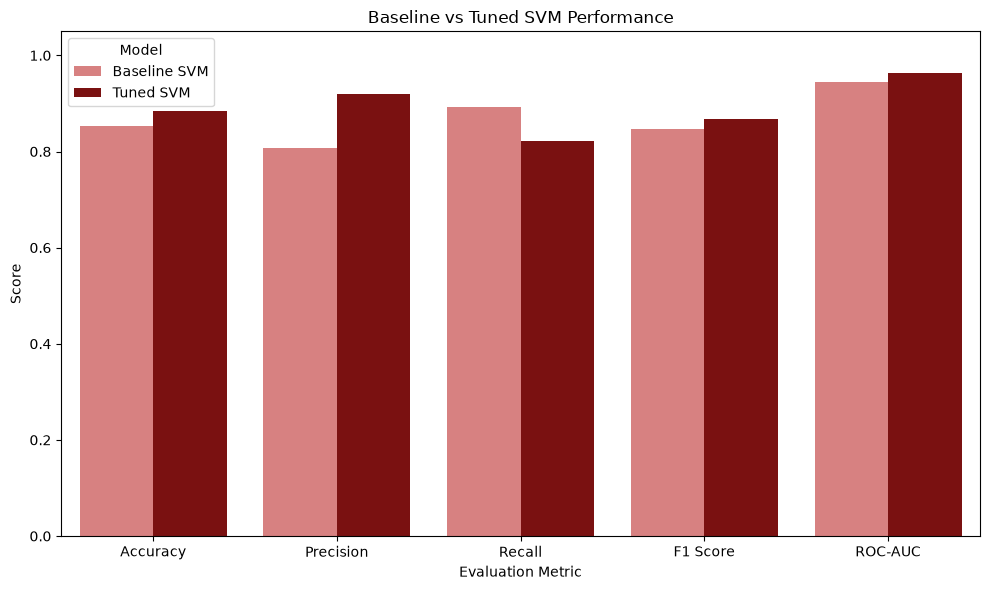

In [59]:
# Visualize baseline and tuned SVM performance

comparison_plot = model_comparison.melt(
    id_vars="Metric",
    var_name="Model",
    value_name="Score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison_plot,
    x="Metric",
    y="Score",
    hue="Model",
    palette=["#E57373", "#8B0000"]
)

plt.ylim(0, 1.05)
plt.title("Baseline vs Tuned SVM Performance")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

plt.tight_layout()
plt.savefig(
    "outputs/figures/baseline_vs_tuned_svm.png",
    dpi=300
)
plt.show()

### Hyperparameter Tuning Insights

- Grid Search evaluates alternative SVM configurations using only the training data.
- Stratified cross-validation maintains the class distribution within each validation fold.
- ROC-AUC is used to select the best configuration based on discrimination across classification thresholds.
- The final selected model is evaluated separately on the untouched test set.
- Comparing baseline and tuned performance shows whether hyperparameter optimization improves generalization rather than relying only on cross-validation performance.

## 12. Model Serialization

The final tuned Support Vector Machine and the fitted StandardScaler are saved for future inference.

Saving both objects is essential because new observations must undergo the same feature scaling used during model training before being passed to the SVM classifier.

In [60]:
# Save the final tuned SVM model and fitted feature scaler

joblib.dump(
    best_svm_model,
    "models/svm_heart_disease.pkl"
)

joblib.dump(
    scaler,
    "models/standard_scaler.pkl"
)

print("Final SVM model saved successfully.")
print("StandardScaler saved successfully.")

Final SVM model saved successfully.
StandardScaler saved successfully.


In [61]:
# Save the feature names and their required input order

feature_order = pd.DataFrame({
    "Position": range(1, len(X.columns) + 1),
    "Feature": X.columns
})

feature_order.to_csv(
    "outputs/tables/model_feature_order.csv",
    index=False
)

feature_order

,Position,Feature
0,1,age
1,2,sex
2,3,cp
3,4,trestbps
4,5,chol
5,6,fbs
6,7,restecg
7,8,thalach
8,9,exang
9,10,oldpeak


In [62]:
# Reload the serialized model and scaler to verify successful persistence

loaded_model = joblib.load(
    "models/svm_heart_disease.pkl"
)

loaded_scaler = joblib.load(
    "models/standard_scaler.pkl"
)

verification_sample = X_test.iloc[[0]]
verification_scaled = loaded_scaler.transform(verification_sample)

verification_prediction = loaded_model.predict(
    verification_scaled
)[0]

print(
    "Reloaded model prediction:",
    "Heart Disease" if verification_prediction == 1 else "No Heart Disease"
)

print(
    "Original model prediction:",
    "Heart Disease" if tuned_pred[0] == 1 else "No Heart Disease"
)

print(
    "Serialization verified:",
    verification_prediction == tuned_pred[0]
)

Reloaded model prediction: No Heart Disease
Original model prediction: No Heart Disease
Serialization verified: True


### Model Serialization Insights

- The tuned SVM classifier was saved as the final predictive model.
- The fitted StandardScaler was stored separately so future observations undergo identical preprocessing.
- The expected feature order was also preserved to prevent incorrect feature alignment during inference.
- Reloading the serialized objects and reproducing an existing prediction verifies that the saved model can be used independently of the training process.

## 13. Final Prediction Pipeline

The serialized model can be used to perform inference on new patient observations without retraining the classifier.

A new observation must contain the same 13 clinical features, in the same order used during training. The saved StandardScaler first transforms the input before the trained SVM generates the final classification and probability estimate.

In [63]:
# Select one unseen patient record as an example input

sample_patient = X_test.iloc[[0]].copy()

sample_patient

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
219,59.0,1.0,4.0,138.0,271.0,0.0,2.0,182.0,0.0,0.0,1.0,0.0,3.0


In [64]:
# Load the trained SVM model and preprocessing scaler

prediction_model = joblib.load("models/svm_heart_disease.pkl")
prediction_scaler = joblib.load("models/standard_scaler.pkl")

In [65]:
# Transform the patient data and generate a heart disease prediction

sample_scaled = prediction_scaler.transform(sample_patient)

sample_prediction = prediction_model.predict(sample_scaled)[0]
sample_probability = prediction_model.predict_proba(sample_scaled)[0]

diagnosis = (
    "Heart Disease"
    if sample_prediction == 1
    else "No Heart Disease"
)

print("Predicted Diagnosis:", diagnosis)
print("No Disease Probability:", round(sample_probability[0], 4))
print("Heart Disease Probability:", round(sample_probability[1], 4))

Predicted Diagnosis: No Heart Disease
No Disease Probability: 0.8305
Heart Disease Probability: 0.1695


In [66]:
# Compare the predicted diagnosis with the patient's actual test label

actual_value = y_test.loc[sample_patient.index[0]]

actual_diagnosis = (
    "Heart Disease"
    if actual_value == 1
    else "No Heart Disease"
)

print("Actual Diagnosis:", actual_diagnosis)
print("Predicted Diagnosis:", diagnosis)
print("Correct Prediction:", actual_value == sample_prediction)

Actual Diagnosis: No Heart Disease
Predicted Diagnosis: No Heart Disease
Correct Prediction: True


In [67]:
# Save the example patient and prediction results

sample_prediction_result = sample_patient.copy()

sample_prediction_result["Actual Diagnosis"] = actual_diagnosis
sample_prediction_result["Predicted Diagnosis"] = diagnosis
sample_prediction_result["No Disease Probability"] = sample_probability[0]
sample_prediction_result["Heart Disease Probability"] = sample_probability[1]

sample_prediction_result.to_csv(
    "outputs/tables/final_prediction_example.csv",
    index=False
)

sample_prediction_result

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Actual Diagnosis,Predicted Diagnosis,No Disease Probability,Heart Disease Probability
219,59.0,1.0,4.0,138.0,271.0,0.0,2.0,182.0,0.0,0.0,1.0,0.0,3.0,No Heart Disease,No Heart Disease,0.830514,0.169486


### Prediction Pipeline Insights

- The saved StandardScaler applies the preprocessing learned exclusively from the original training data.
- The transformed observation is passed to the tuned SVM classifier for inference.
- The model returns both a binary diagnosis and class probability estimates.
- This pipeline demonstrates how the trained model can be reused independently without repeating the training process.